💡 **Environment:** `clamp-analyses`


# Supplementary Figure 5: ARCHS4 projection mechanism recovery -- GTEx/pseudobulk (A), and cytokine/monocyte/placenta paper-defined mechanisms (B-D)

A is Fig. 3's previous Panel H (GTEx tissue ARI and pseudobulk cell-type recovery, K-matched), moved here after Fig. 3 H was replaced with the cytokine mechanism-recovery panels.

B-D follow nbs/03_model_biology/02_archs4/03_projections/{00_cytokines,01_monocyte,02_placenta}.ipynb: the mechanism-heatmap tile (headline gene-set-fraction view), the paper-defined-mechanism dotplot (local vs. ARCHS4 projection), and every individual gene-set-pair ranking plot for that dataset. B shows only the cytokine mechanisms not already used in Fig. 3 H (everything except ISG_core).


In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(patchwork)
  library(cowplot)
  library(ggrastr)
  library(ggpubr)
  library(yaml)
  library(here)
})


In [2]:
cfg <- yaml::read_yaml(here("config.yaml"))

FS_TAG          <- 9
FS_TITLE        <- 6.5
FS_AXIS_TITLE   <- 6.5
FS_AXIS_TEXT    <- 5
FS_LEGEND       <- 5
FS_LEGEND_TITLE <- 5.5

FIG_W <- 183
FIG_H <- 1050
stopifnot(FIG_W == 183, FIG_H == 1050)

DATA_DIR <- here("output/03_model_biology/02_archs4")

theme_nm <- function(base_size = FS_AXIS_TEXT, base_line_size = 0.25) {
  theme_classic(base_size = base_size, base_family = "Helvetica") %+replace%
    theme(
      axis.line = element_line(linewidth = base_line_size, colour = "black"),
      axis.ticks = element_line(linewidth = base_line_size, colour = "black"),
      axis.ticks.length = unit(1.1, "mm"),
      axis.text = element_text(size = FS_AXIS_TEXT, colour = "black"),
      axis.title = element_text(size = FS_AXIS_TITLE, face = "plain", colour = "black"),
      legend.text = element_text(size = FS_LEGEND),
      legend.title = element_text(size = FS_LEGEND_TITLE, face = "plain"),
      legend.key = element_blank(),
      legend.background = element_blank(),
      strip.background = element_blank(),
      strip.text = element_text(size = FS_TITLE, face = "bold", margin = margin(b = 0.7)),
      panel.grid = element_blank(),
      plot.margin = margin(1.3, 1.3, 1.3, 1.3)
    )
}

add_tag <- function(p, label, x = 0.002, y = 0.998) {
  ggdraw() +
    draw_plot(p, x = 0, y = 0, width = 1, height = 1) +
    draw_label(label, x = x, y = y, hjust = 0, vjust = 1,
               size = FS_TAG, fontface = "bold", fontfamily = "Helvetica")
}

section_title <- function(label) {
  ggdraw() + draw_label(label, x = 0.01, hjust = 0, fontface = "bold", size = FS_TITLE + 1)
}


## Panel A: ARCHS4 projections -- GTEx tissue ARI (A1) and pseudobulk cell-type recovery (A2), K-matched

(Previously Fig. 3's Panel H.)


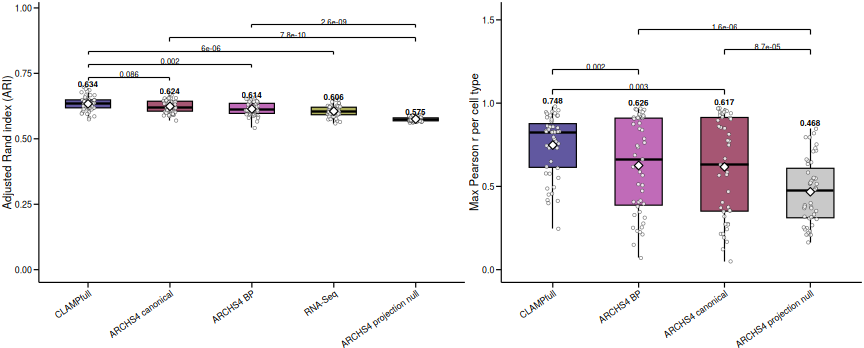

In [3]:
# Follows nbs/03_model_biology/02_archs4/03_projections/05_gtex_ari.ipynb
# (A1) and 04_pseudobulk_recovery.ipynb (A2): K-matched recovery of ARCHS4
# BP/canonical projections vs. locally fit CLAMPfull, RNA-Seq, and a
# permuted-loading projection null, with paired Wilcoxon tests (unadjusted,
# matching the source notebooks).
fmt_p_A <- function(p) if (p < 0.001) format(p, scientific = TRUE, digits = 2) else sprintf("%.3f", p)

plot_recovery_A <- function(d, comparisons, value_col, y_label, colours,
                             y_base_pad, y_step, bracket_h, label_pad, mean_label_pad) {
  means <- d[, .(mean_v = mean(get(value_col)), max_v = max(get(value_col))), by = method]
  setorder(means, -mean_v)
  d <- copy(d)
  d[, method := factor(method, levels = means$method)]
  means[, method := factor(method, levels = means$method)]
  y_base <- max(means$max_v) + y_base_pad
  y_max  <- y_base + nrow(comparisons) * y_step

  p <- ggplot(d, aes(method, .data[[value_col]], fill = method)) +
    geom_boxplot(outlier.shape = NA, width = 0.55, colour = "black", linewidth = 0.25, alpha = 0.82) +
    geom_jitter(width = 0.08, shape = 21, size = 0.55, fill = "white", colour = "#4d4d4d",
                stroke = 0.2, alpha = 0.8) +
    geom_point(data = means, aes(x = method, y = mean_v), inherit.aes = FALSE, shape = 23,
               size = 1.7, fill = "white", colour = "black", stroke = 0.35) +
    geom_text(data = means, aes(x = method, y = max_v + mean_label_pad, label = sprintf("%.3f", mean_v)),
              inherit.aes = FALSE, fontface = "bold", size = 1.6) +
    scale_fill_manual(values = colours) +
    coord_cartesian(ylim = c(0, y_max), clip = "off") +
    labs(x = NULL, y = y_label) +
    theme_nm() +
    theme(axis.text.x = element_text(angle = 35, hjust = 1), legend.position = "none")

  for (i in seq_len(nrow(comparisons))) {
    a <- comparisons$a[i]; b <- comparisons$b[i]
    va <- d[method == a][order(replicate)][[value_col]]
    vb <- d[method == b][order(replicate)][[value_col]]
    p_value <- suppressWarnings(wilcox.test(va, vb, paired = TRUE)$p.value)
    x1 <- match(a, levels(d$method)); x2 <- match(b, levels(d$method))
    y <- y_base + (i - 1) * y_step
    p <- p +
      annotate("segment", x = x1, xend = x1, y = y, yend = y + bracket_h, linewidth = 0.25) +
      annotate("segment", x = x1, xend = x2, y = y + bracket_h, yend = y + bracket_h, linewidth = 0.25) +
      annotate("segment", x = x2, xend = x2, y = y + bracket_h, yend = y, linewidth = 0.25) +
      annotate("text", x = (x1 + x2) / 2, y = y + bracket_h + label_pad, label = fmt_p_A(p_value), size = 1.5)
  }
  p
}

# A1: GTEx tissue recovery (k-means ARI vs SMTSD), K = 578
gtex_dir   <- here("output/03_model_biology/02_archs4/03_projections/05_gtex_ari_archs4")
bp_gtex    <- fread(file.path(gtex_dir, "gtex_bp_dim.csv"))
canon_gtex <- fread(file.path(gtex_dir, "gtex_canon_dim.csv"))
null_gtex  <- fread(file.path(gtex_dir, "dim_control.csv"))
local_ari  <- fread(here("output/03_model_biology/01_gtex/00_kmeans_clustering/ari_data.csv"))

method_colours_A1 <- c(CLAMPfull = "#3e348b", "ARCHS4 canonical" = "#923155",
                       "ARCHS4 BP" = "#b24ba8", "RNA-Seq" = "#9c9f36",
                       "ARCHS4 projection null" = "#999999")

k_matched_gtex <- rbindlist(list(
  local_ari[method == "CLAMPfull", .(method = "CLAMPfull", ARI = ari, replicate = .I)],
  canon_gtex[, .(method = "ARCHS4 canonical", ARI = canon_578, replicate = .I)],
  bp_gtex[, .(method = "ARCHS4 BP", ARI = bp_578, replicate = .I)],
  local_ari[method == "RNA-Seq", .(method = "RNA-Seq", ARI = ari, replicate = .I)],
  null_gtex[, .(method = "ARCHS4 projection null", ARI = null_578, replicate = .I)]
))

comparisons_A1 <- data.table(
  a = c("CLAMPfull", "CLAMPfull", "CLAMPfull", "ARCHS4 canonical", "ARCHS4 BP"),
  b = c("ARCHS4 canonical", "ARCHS4 BP", "RNA-Seq", "ARCHS4 projection null", "ARCHS4 projection null")
)

plot_A1 <- plot_recovery_A(k_matched_gtex, comparisons_A1, "ARI", "Adjusted Rand index (ARI)",
                            method_colours_A1, 0.025, 0.05, 0.012, 0.011, 0.010)

# A2: pseudobulk cell-type recovery, K-matched
pb_dir       <- here("output/03_model_biology/02_archs4/03_projections/04_pseudobulk_recovery_archs4")
bp_pb        <- fread(file.path(pb_dir, "pb_bp_flat_dim.csv"))
canon_pb     <- fread(file.path(pb_dir, "pb_canon_dim.csv"))
clampnull_pb <- fread(file.path(pb_dir, "pb_dimcontrol.csv"))

method_colours_A2 <- c(CLAMPfull = "#3e348b", "ARCHS4 canonical" = "#923155",
                       "ARCHS4 BP" = "#b24ba8", "ARCHS4 projection null" = "#bdbdbd")

k_matched_pb <- rbindlist(list(
  clampnull_pb[, .(method = "CLAMPfull", value = clampfull_k, replicate = paste(dataset, cell_type))],
  canon_pb[, .(method = "ARCHS4 canonical", value = canon_k, replicate = paste(dataset, cell_type))],
  bp_pb[, .(method = "ARCHS4 BP", value = bp_k, replicate = paste(dataset, cell_type))],
  clampnull_pb[, .(method = "ARCHS4 projection null", value = null_k, replicate = paste(dataset, cell_type))]
))

comparisons_A2 <- data.table(
  a = c("CLAMPfull", "CLAMPfull", "ARCHS4 canonical", "ARCHS4 BP"),
  b = c("ARCHS4 canonical", "ARCHS4 BP", "ARCHS4 projection null", "ARCHS4 projection null")
)

plot_A2 <- plot_recovery_A(k_matched_pb, comparisons_A2, "value", "Max Pearson r per cell type",
                            method_colours_A2, 0.07, 0.12, 0.03, 0.018, 0.035)

plot_A <- plot_grid(plot_A1, plot_A2, nrow = 1, rel_widths = c(1, 0.85))

options(repr.plot.width = 7.2, repr.plot.height = 2.9)
print(plot_A)


## Panels B-D: ARCHS4 projection vs. local model -- cytokine, monocyte, placenta mechanism recovery


In [4]:
# Reuses the projection-report plotting helpers (translated for this compact
# multi-panel layout: smaller fonts/point sizes than their source report
# context) to build every mechanism-heatmap tile, expected-mechanism dotplot,
# and gene-set-pair ranking plot for each dataset.
source(here("scripts", "projections", "plots.R"))

agg_dir_proj <- file.path(DATA_DIR, "03_projections", "aggregate")
mech_all        <- fread(file.path(agg_dir_proj, "mechanism_recovery_long.csv"))
lv_stats_all    <- fread(file.path(agg_dir_proj, "lv_stats_long.csv"))
comparisons_all <- fread(file.path(agg_dir_proj, "gene_set_comparisons_long.csv"))
loadings_all    <- fread(file.path(agg_dir_proj, "gene_set_loading_points_long.csv"))

# One tile heatmap + a wrapped grid of every gene-set-pair plot for a group's
# dataset, optionally excluding some comparison_ids (cytokines' ISG_core,
# already shown in Fig. 3 H) and optionally prefixed by the expected-mechanism
# dotplot (skipped for cytokines, already in Fig. 3 H).
build_projection_block <- function(group_sel, exclude_ids = character(0), include_dotplot = TRUE, ncol_pairs = 2) {
  mech        <- mech_all[group == group_sel & category %in% c("molecular_mechanism", "cell_type")]
  comparisons <- comparisons_all[group == group_sel & category %in% c("molecular_mechanism", "cell_type")]
  lv_stats    <- lv_stats_all[group == group_sel]
  loadings    <- loadings_all[group == group_sel]
  dsel <- unique(mech$dataset)
  stopifnot(length(dsel) == 1L)

  tile <- proj_mechanism_heatmap(mech, comparisons, dsel)
  parts <- list(tile)
  heights <- c(2.5 + 0.5 * uniqueN(mech$mechanism))

  if (include_dotplot) {
    dotplot <- proj_expected_mechanism_heatmap(lv_stats, comparisons, dsel)
    n_rows <- vapply(c("local", "ARCHS4"), function(m) uniqueN(comparisons[
      model == m & recovered == TRUE, .(mechanism, LV)]), integer(1))
    parts <- c(parts, list(dotplot))
    heights <- c(heights, 0.9 * sum(pmax(1, n_rows + 1L)))
  }

  ids <- setdiff(unique(comparisons$comparison_id), exclude_ids)
  pair_plots <- lapply(ids, function(id) {
    proj_gene_set_pair_plot(comparisons, loadings, dsel, id)
  })
  pair_plots <- Filter(Negate(is.null), pair_plots)
  pairs_grid <- patchwork::wrap_plots(pair_plots, ncol = ncol_pairs)
  n_pair_rows <- ceiling(length(pair_plots) / ncol_pairs)
  parts <- c(parts, list(pairs_grid))
  heights <- c(heights, 4.2 * n_pair_rows)

  patchwork::wrap_plots(parts, ncol = 1, heights = heights)
}


### Panel B: cytokines (IFN-alpha), mechanisms not already shown in Fig. 3 H


In [5]:
plot_B <- build_projection_block("cytokines", exclude_ids = "ISG_core::hallmark", include_dotplot = FALSE)


### Panel C: monocyte (LPS)


In [6]:
plot_C <- build_projection_block("monocyte")


### Panel D: placenta (trophoblast vs. other)


In [7]:
plot_D <- build_projection_block("placenta")


## Assemble and save


In [8]:
supp5 <- plot_grid(
  add_tag(plot_A, "A"),
  section_title("B: cytokines (IFN-alpha) -- mechanisms not shown in Fig. 3 H"),
  add_tag(plot_B, "B", y = 1),
  section_title("C: monocyte (LPS)"),
  add_tag(plot_C, "C", y = 1),
  section_title("D: placenta (trophoblast vs. other)"),
  add_tag(plot_D, "D", y = 1),
  ncol = 1,
  rel_heights = c(0.055, 0.012, 0.14, 0.012, 0.22, 0.012, 0.30)
)

out_dir <- here("output/99_panels/supp5")
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

raw_pdf <- tempfile(fileext = ".pdf")
ggsave(raw_pdf, supp5, width = FIG_W, height = FIG_H, units = "mm",
       device = cairo_pdf, bg = "white", limitsize = FALSE)

if (nzchar(Sys.which("gs"))) {
  exact_pdf <- tempfile(fileext = ".pdf")
  pdf_w_pt <- FIG_W / 25.4 * 72
  pdf_h_pt <- FIG_H / 25.4 * 72
  gs_status <- system2("gs", c(
    "-q", "-dNOPAUSE", "-dBATCH", "-sDEVICE=pdfwrite",
    sprintf("-dDEVICEWIDTHPOINTS=%.6f", pdf_w_pt),
    sprintf("-dDEVICEHEIGHTPOINTS=%.6f", pdf_h_pt),
    "-dFIXEDMEDIA", "-dPDFFitPage",
    paste0("-sOutputFile=", exact_pdf), raw_pdf
  ))
  stopifnot(gs_status == 0L)
  file.copy(exact_pdf, file.path(out_dir, "supp5.pdf"), overwrite = TRUE)
  unlink(exact_pdf)
} else {
  file.copy(raw_pdf, file.path(out_dir, "supp5.pdf"), overwrite = TRUE)
}
unlink(raw_pdf)

ggsave(file.path(out_dir, "supp5.svg"), supp5, width = FIG_W, height = FIG_H,
       units = "mm", device = svglite::svglite, bg = "white", limitsize = FALSE)
ggsave(file.path(out_dir, "supp5.png"), supp5, width = FIG_W, height = FIG_H,
       units = "mm", dpi = 300, device = ragg::agg_png, bg = "white", limitsize = FALSE)

cat(sprintf("supp5: %.0f x %.0f mm -> %s\n", FIG_W, FIG_H, out_dir))
options(repr.plot.width = FIG_W / 25.4, repr.plot.height = FIG_H / 25.4)
supp5


supp5: 183 x 1050 mm -> /home/msubirana/Documents/pivlab/clamp-analyses-archs4_panel/output/99_panels/supp5


ERROR while rich displaying an object: Error in grid.Call(C_convert, x, as.integer(whatfrom), as.integer(whatto), : Viewport has zero dimension(s)

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepar